<a href="https://colab.research.google.com/github/genaiconference/Agentic_KAG_Workshop_DHS_2026/blob/main/00_introduction_to_knowledge_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Introduction to Knowledge Graphs & Graph Types

### Workshop — *Beyond Agentic RAG: Building Graph-Powered, Knowledge-Driven GenAI Systems*

**Notebook 00 · The concepts, before the code**

This is the **first** notebook in the series. Before we connect to databases, build pipelines, or wire up retrievers, we need a shared mental model. This notebook introduces the **core concepts of knowledge graphs** and the **types of graphs** that power modern GenAI systems:

- the **domain graph** (entities & relationships),
- the **lexical graph** (documents & chunks),
- the **parent–child graph** (hierarchical context), and
- the **community graph** (clusters & themes).

> 🧩 **Self-contained & offline.** No Neo4j, no API keys. Every idea is illustrated with small, runnable `networkx` examples so you can *see* each concept.

## 🎯 Learning Objectives

By the end of this notebook you will be able to:

1. Explain what a **knowledge graph** is and why graphs beat tables/vectors for connected data.
2. Describe the **property graph model**: nodes, relationships, properties, and labels.
3. Distinguish the four graph types used in GraphRAG: **domain**, **lexical**, **parent–child**, and **community**.
4. Recognise how these layers **combine** to enable knowledge-driven retrieval and reasoning.
5. Build and visualise each graph type yourself with `networkx`.

**Stack:** Python 3.12 · `networkx` · `matplotlib` (concepts only — later notebooks use Neo4j + `neo4j-graphrag` + LangChain).

## 🗺️ Table of Contents

1. What Is a Knowledge Graph?
2. The Property Graph Model (nodes, relationships, properties, labels)
3. Why Graphs? (tables vs vectors vs graphs)
4. The Four Graph Types — Overview
5. Domain Graph
6. Lexical Graph
7. Parent–Child Graph
8. Community Graph
9. How the Layers Combine in GraphRAG
10. Side-by-Side Comparison
11. Exercises
12. Summary & Next Steps

## 1 · What Is a Knowledge Graph?

A **knowledge graph (KG)** represents information as a **network of facts** rather than rows in a table or isolated text chunks. Each fact is a small statement:

> **(Inception) —[DIRECTED_BY]→ (Christopher Nolan)**

Chain millions of these statements together and you get a *queryable web of knowledge* where the **relationships are first-class citizens** — they carry meaning, direction, and type.
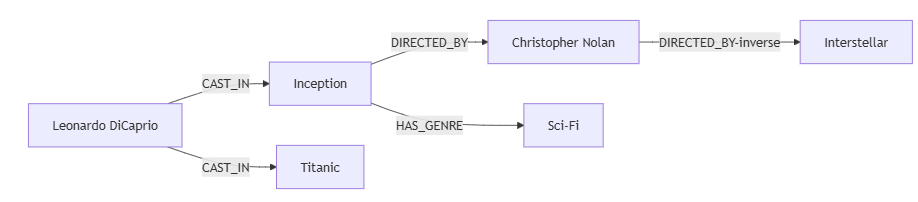

**The key idea:** in a KG, *meaning lives in the connections*. That is what lets us answer questions like *“which actors have worked with Nolan?”* by **following edges** — something flat text or vector stores struggle to do reliably.

### Setup

We only need `networkx` (graphs) and `matplotlib` (drawing). Run the install cell once; skip it if they are already present.

In [1]:
%pip install -q -U networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.9 MB/s eta 0:00:00


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(G, title, node_colors=None, figsize=(11, 7), seed=7, node_size=1700):
    """Reusable helper to draw a labelled graph with edge-type labels."""
    pos = nx.spring_layout(G, seed=seed, k=0.9)
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors or '#8ecae6',
                           node_size=node_size, alpha=0.95, edgecolors='#023047')
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=16,
                           edge_color='#adb5bd', width=1.4)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    edge_labels = nx.get_edge_attributes(G, 'label')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                     font_size=7, font_color='#d90429')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('networkx version :', nx.__version__)
print('draw_graph() helper ready')

networkx version : 3.6.1
draw_graph() helper ready


## 2 · The Property Graph Model

Neo4j (and most KG tools) use the **property graph model**, built from four primitives:

| Primitive | What it is | Movie example |
|-----------|-----------|---------------|
| **Node** | An entity / thing | a `Movie`, a `Person` |
| **Relationship** | A *typed, directed* edge between nodes | `(:Person)-[:DIRECTED]->(:Movie)` |
| **Property** | A key–value attribute on a node **or** relationship | `title: 'Inception'`, `year: 2010` |
| **Label** | A category/tag grouping similar nodes | `:Movie`, `:Person`, `:Genre` |

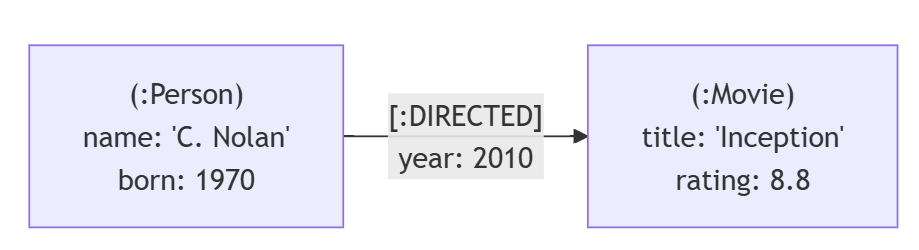

Below we encode exactly that fact in `networkx`, attaching **properties to both the nodes and the relationship**.

In [3]:
# A minimal property graph: two labelled nodes + one typed relationship, all with properties
pg = nx.DiGraph()

# Nodes carry a label + properties
pg.add_node('nolan', label='Person', name='Christopher Nolan', born=1970)
pg.add_node('inception', label='Movie', title='Inception', rating=8.8, year=2010)

# Relationship carries a type + properties
pg.add_edge('nolan', 'inception', label='DIRECTED', year=2010)

print('Nodes and their properties:')
for node_id, props in pg.nodes(data=True):
    print(f'  ({props["label"]}) {node_id} -> {props}')

print('\nRelationships and their properties:')
for src, dst, props in pg.edges(data=True):
    print(f'  ({src})-[:{props["label"]} {props}]->({dst})')

Nodes and their properties:
  (Person) nolan -> {'label': 'Person', 'name': 'Christopher Nolan', 'born': 1970}
  (Movie) inception -> {'label': 'Movie', 'title': 'Inception', 'rating': 8.8, 'year': 2010}

Relationships and their properties:
  (nolan)-[:DIRECTED {'label': 'DIRECTED', 'year': 2010}]->(inception)


## 3 · Why Graphs? Tables vs Vectors vs Graphs

Three common ways to store knowledge — each optimised for a different question shape:

| Approach | Great at | Struggles with |
|----------|----------|----------------|
| **Relational tables** | Exact records, aggregates | Deep/variable-hop joins get expensive & rigid |
| **Vector store** | *Semantic similarity* over text | Structure, multi-hop, aggregation, explainability |
| **Knowledge graph** | *Relationships & traversal* | Pure fuzzy semantic recall (so we **combine** it with vectors) |

A question like *“which actors connect Nolan to DiCaprio through shared movies?”* is a **traversal** — natural for a graph, awkward for tables, and nearly impossible for a bare vector store. GraphRAG's superpower is that it **doesn't force a choice**: it layers vectors *on top of* a graph.

## 4 · The Four Graph Types — Overview

A production GraphRAG system rarely uses just one kind of graph. It **layers** several, each serving a purpose:
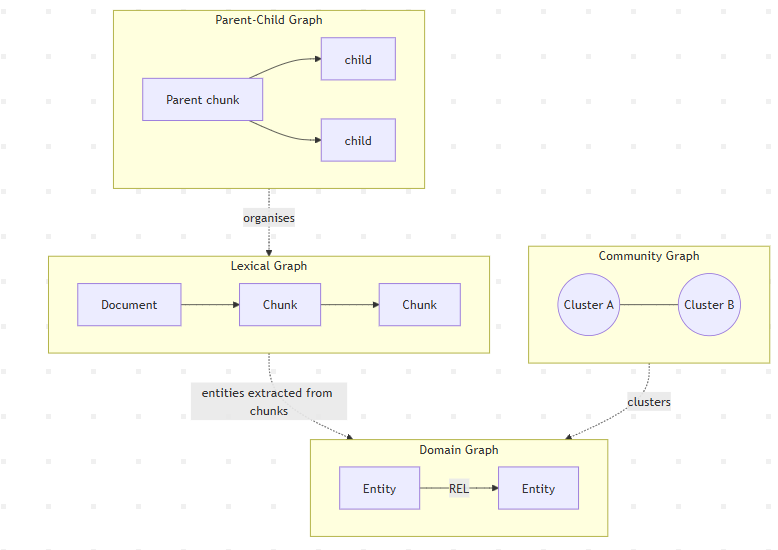

| Graph type | Nodes | Answers questions about… |
|-----------|-------|--------------------------|
| **Domain** | real-world entities | *facts & relationships* (who directed what) |
| **Lexical** | documents & chunks | *source text & citations* (where was this said) |
| **Parent–child** | coarse ↔ fine chunks | *precision vs context* (retrieve small, read big) |
| **Community** | clusters of nodes | *themes & the big picture* (summaries) |

Let's build and visualise each one. 👇

## 5 · Domain Graph — *the knowledge itself*

The **domain graph** captures **real-world entities and the typed relationships between them**. It is the *extracted knowledge* — the layer you traverse to reason.

- **Nodes:** `Movie`, `Person`, `Genre`, `Country`, …
- **Relationships:** `DIRECTED_BY`, `CAST_IN`, `HAS_GENRE`, …

This is what enables **multi-hop** questions: *Person →[CAST_IN]→ Movie ←[DIRECTED_BY]← Person* finds actors who worked with a director.

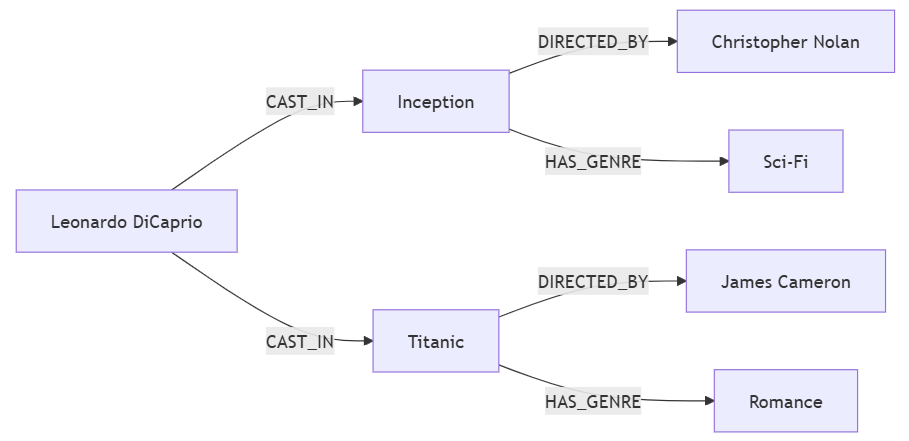

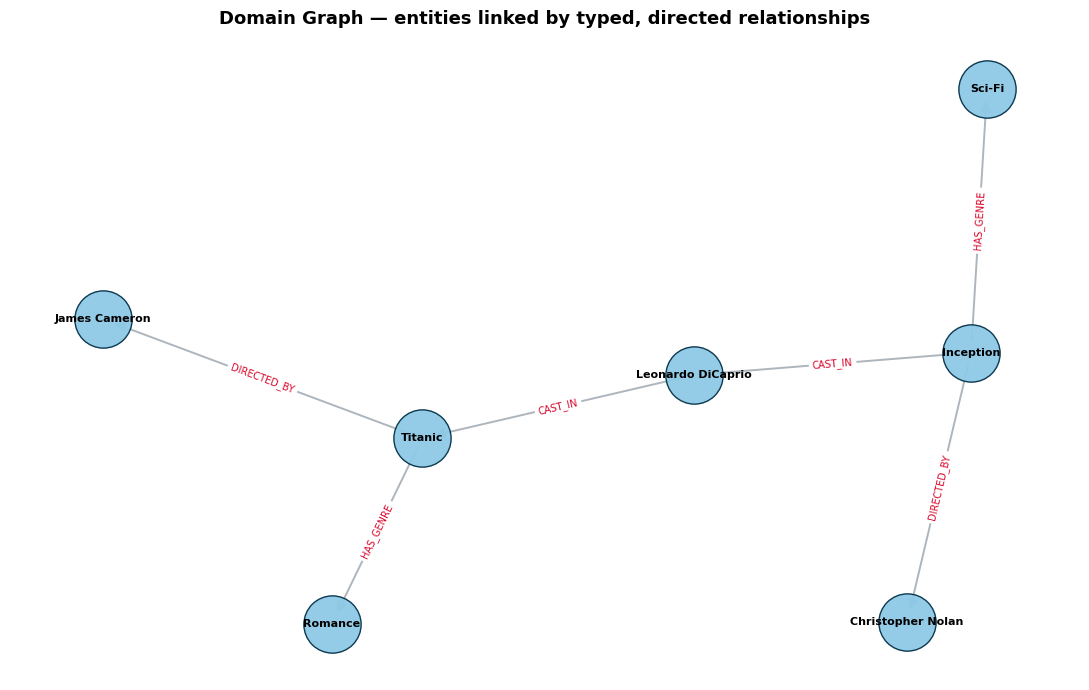

Directors connected to Leonardo DiCaprio via a shared movie:
  Leonardo DiCaprio --CAST_IN--> Inception --DIRECTED_BY--> Christopher Nolan
  Leonardo DiCaprio --CAST_IN--> Titanic --DIRECTED_BY--> James Cameron


In [4]:
# Build a small DOMAIN graph: entities connected by typed relationships
domain = nx.DiGraph()
domain.add_edge('Leonardo DiCaprio', 'Inception', label='CAST_IN')
domain.add_edge('Leonardo DiCaprio', 'Titanic',   label='CAST_IN')
domain.add_edge('Inception', 'Christopher Nolan',  label='DIRECTED_BY')
domain.add_edge('Titanic',   'James Cameron',      label='DIRECTED_BY')
domain.add_edge('Inception', 'Sci-Fi',             label='HAS_GENRE')
domain.add_edge('Titanic',   'Romance',            label='HAS_GENRE')

draw_graph(domain, 'Domain Graph — entities linked by typed, directed relationships')

# A multi-hop traversal a vector store cannot do: who has DiCaprio worked with (directors)?
print('Directors connected to Leonardo DiCaprio via a shared movie:')
for movie in domain.successors('Leonardo DiCaprio'):
    for target in domain.successors(movie):
        if domain.edges[movie, target]['label'] == 'DIRECTED_BY':
            print(f'  Leonardo DiCaprio --CAST_IN--> {movie} --DIRECTED_BY--> {target}')

## 6 · Lexical Graph — *the source text, structured*

The **lexical graph** preserves the **original documents split into ordered chunks**. It is the *grounding* layer: it gives the LLM quotable text and lets you cite sources.

- **Nodes:** `Document`, `Chunk`
- **Relationships:** `FROM_DOCUMENT` (provenance), `NEXT_CHUNK` (reading order)
- **Property:** each `Chunk` usually stores an **embedding** → this is what a **vector index** searches.

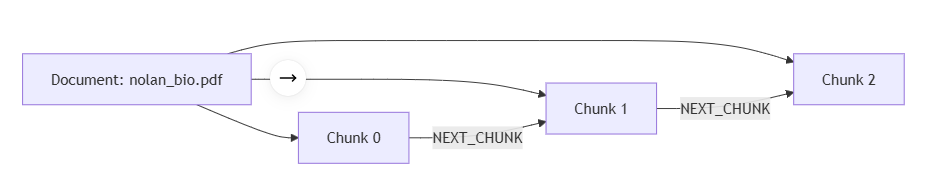

The lexical graph is the **bridge to the domain graph**: entities are *extracted from chunks*, so you can trace any fact back to the exact text that stated it.

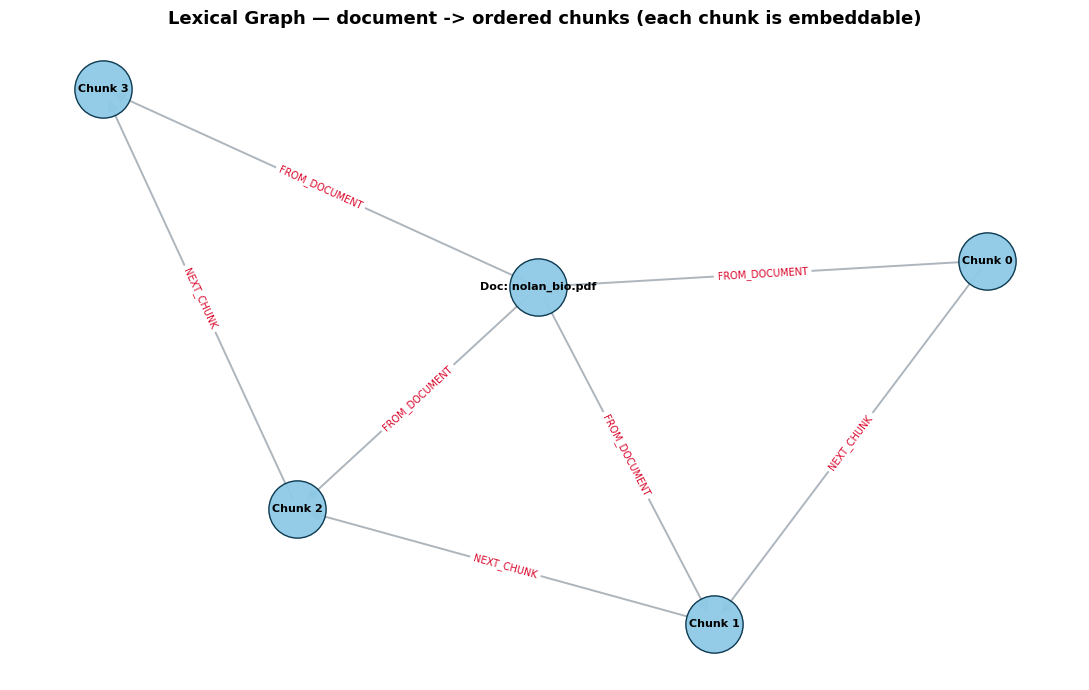

Each Chunk stores an embedding used by the VECTOR INDEX, e.g.: [vector_0 ...]


In [5]:
# Build a small LEXICAL graph: a document split into ordered, embeddable chunks
lexical = nx.DiGraph()
chunks = ['Chunk 0', 'Chunk 1', 'Chunk 2', 'Chunk 3']
for ch in chunks:
    lexical.add_edge('Doc: nolan_bio.pdf', ch, label='FROM_DOCUMENT')
for a, b in zip(chunks, chunks[1:]):
    lexical.add_edge(a, b, label='NEXT_CHUNK')

# Attach a pretend embedding property to each chunk (a real system stores 1536-dim vectors)
for i, ch in enumerate(chunks):
    lexical.nodes[ch]['embedding'] = f'[vector_{i} ...]'

draw_graph(lexical, 'Lexical Graph — document -> ordered chunks (each chunk is embeddable)')
print('Each Chunk stores an embedding used by the VECTOR INDEX, e.g.:',
      lexical.nodes['Chunk 0']['embedding'])

## 7 · Parent–Child Graph — *retrieve small, read big*

A recurring RAG problem: **small chunks** retrieve precisely but lack context, while **large chunks** carry context but retrieve fuzzily. The **parent–child graph** solves this with a **hierarchy**:

- **Child chunks** — small & specific → **embedded and searched** for precise matches.
- **Parent chunk** — larger passage → **returned to the LLM** for full context.

> Match on the *child*, but hand the *parent* to the model. (This is the classic *parent-document retriever* pattern.)

The same shape also models **document hierarchy**: `Document → Section → Paragraph → Sentence`.

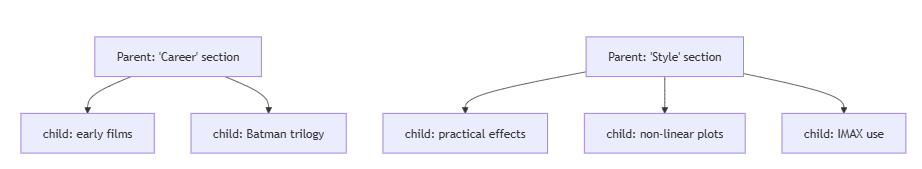

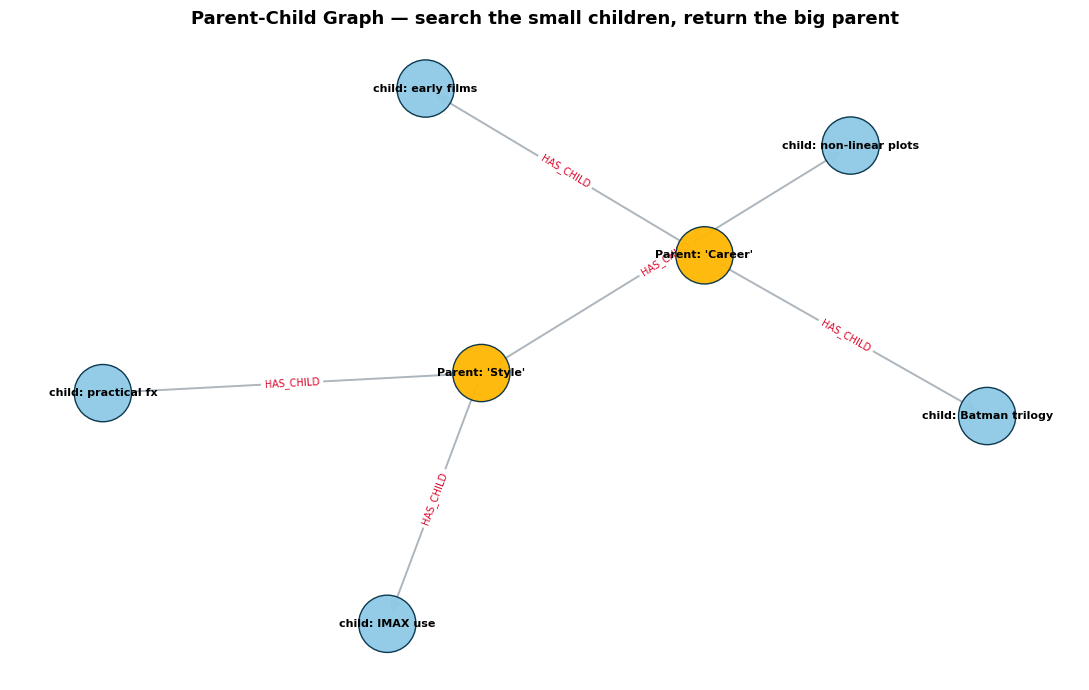

Vector search matched the child: "child: IMAX use"
  -> return its parent to the LLM for context: "Parent: 'Style'"


In [6]:
# Build a PARENT-CHILD graph: parents hold context, children are the precise retrieval units
pc = nx.DiGraph()
hierarchy = {
    "Parent: 'Career'": ['child: early films', 'child: Batman trilogy'],
    "Parent: 'Style'":  ['child: practical fx', 'child: non-linear plots', 'child: IMAX use'],
}
for parent, children in hierarchy.items():
    for child in children:
        pc.add_edge(parent, child, label='HAS_CHILD')

colors = ['#ffb703' if pc.out_degree(n) > 0 else '#8ecae6' for n in pc.nodes()]
draw_graph(pc, 'Parent-Child Graph — search the small children, return the big parent',
           node_colors=colors)

# Simulate the pattern: a child matches -> we return its PARENT for richer context
matched_child = 'child: IMAX use'
parent = next(iter(pc.predecessors(matched_child)))
print(f'Vector search matched the child: "{matched_child}"')
print(f'  -> return its parent to the LLM for context: "{parent}"')

## 8 · Community Graph — *the big picture*

Some questions are **global**, not local: *“what are the main themes across all these movies?”* No single chunk answers that. The **community graph** groups densely-connected nodes into **clusters** (via algorithms like **Louvain** / **Leiden**), and each cluster gets an LLM-written **summary**.

- **Nodes:** entities from the domain graph
- **Communities:** clusters of tightly linked nodes (often **hierarchical** — communities of communities)
- **Use:** answer thematic / global questions from **community summaries** instead of scanning everything.

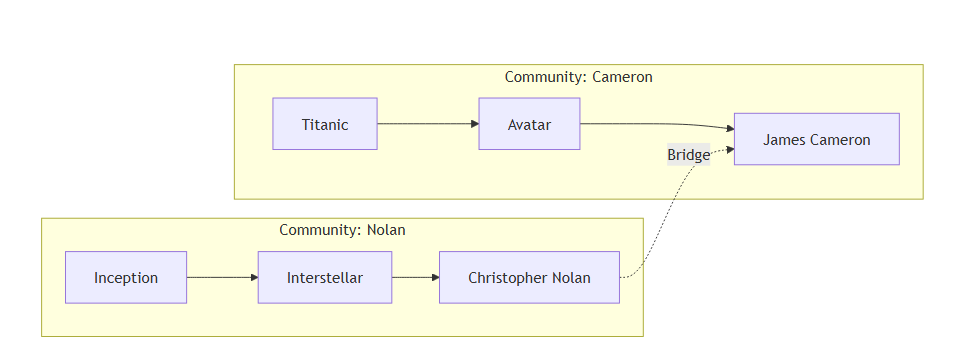

Below we build two loosely-bridged clusters and let `networkx` **detect the communities** automatically.

Detected 2 communities via Louvain:
  Community 0: ['Dunkirk', 'Inception', 'Interstellar', 'Nolan']
  Community 1: ['Aliens', 'Avatar', 'Cameron', 'Titanic']


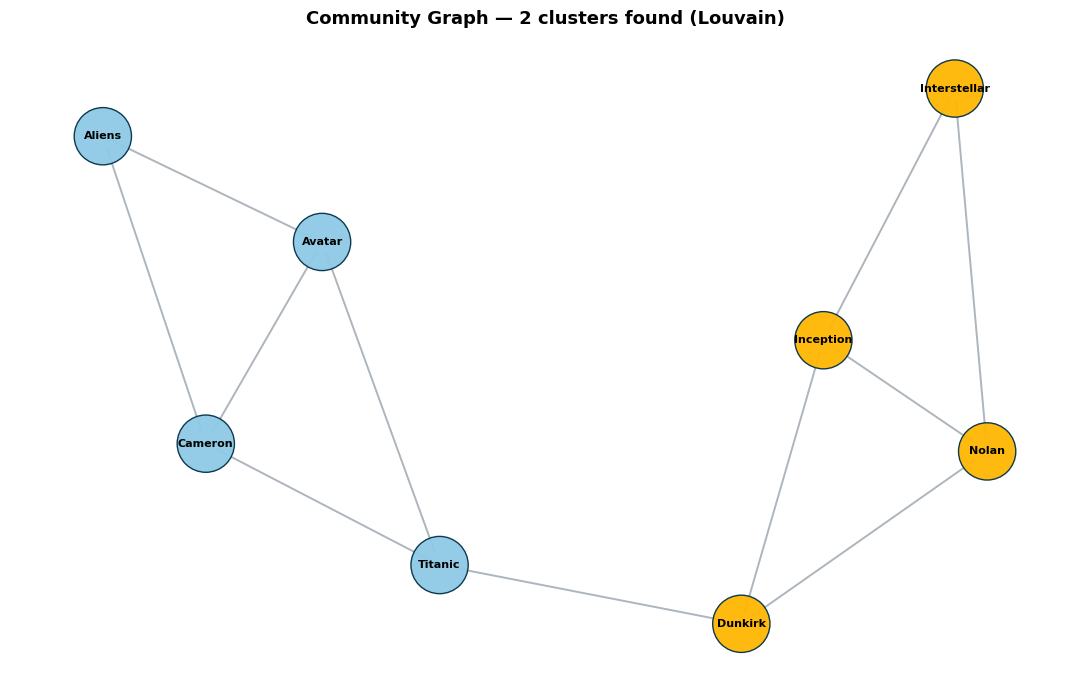

In [7]:
# Build a graph with two dense clusters + a single bridge, then DETECT communities
comm = nx.Graph()
# Cluster 1 (Nolan-ish)
comm.add_edges_from([('Inception', 'Interstellar'), ('Interstellar', 'Nolan'),
                     ('Inception', 'Nolan'), ('Nolan', 'Dunkirk'), ('Inception', 'Dunkirk')])
# Cluster 2 (Cameron-ish)
comm.add_edges_from([('Titanic', 'Avatar'), ('Avatar', 'Cameron'),
                     ('Titanic', 'Cameron'), ('Cameron', 'Aliens'), ('Avatar', 'Aliens')])
# A weak bridge between the two clusters
comm.add_edge('Dunkirk', 'Titanic')

# Community detection (Louvain if available, else greedy modularity)
try:
    from networkx.algorithms.community import louvain_communities
    communities = louvain_communities(comm, seed=42)
    method = 'Louvain'
except Exception:
    from networkx.algorithms.community import greedy_modularity_communities
    communities = [set(c) for c in greedy_modularity_communities(comm)]
    method = 'greedy modularity'

print(f'Detected {len(communities)} communities via {method}:')
for i, c in enumerate(communities):
    print(f'  Community {i}: {sorted(c)}')

# Colour nodes by their detected community
palette = ['#ffb703', '#8ecae6', '#90be6d', '#f4978e', '#cdb4db']
node_color = {}
for i, c in enumerate(communities):
    for node in c:
        node_color[node] = palette[i % len(palette)]
draw_graph(comm, f'Community Graph — {len(communities)} clusters found ({method})',
           node_colors=[node_color[n] for n in comm.nodes()])

## 9 · How the Layers Combine in GraphRAG

The magic is not any single graph — it is how they **work together** to answer a question:

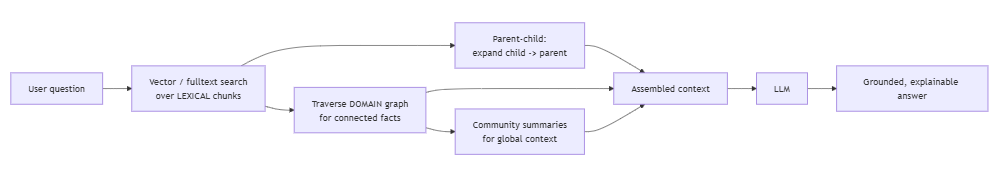`

| Layer | Role in answering a question |
|-------|------------------------------|
| **Lexical** | Find the *most relevant text* (semantic + keyword) |
| **Parent–child** | Widen a precise hit into *enough context* |
| **Domain** | Follow *relationships* for multi-hop facts |
| **Community** | Add *thematic / global* perspective |

**Local questions** lean on lexical + domain; **global questions** lean on community summaries. A good system routes between them — the foundation for the **agentic** behaviour we build later in the series.

## 10 · Side-by-Side Comparison

| | **Domain** | **Lexical** | **Parent–Child** | **Community** |
|--|-----------|-------------|------------------|---------------|
| **Core node** | Entity | Document / Chunk | Parent & child chunks | Cluster of nodes |
| **Built by** | Entity/relation extraction | Document loading + chunking | Multi-granularity chunking | Community detection (Louvain/Leiden) |
| **Powers** | Traversal & reasoning | Grounding & citations | Precision + context balance | Global / thematic answers |
| **Retrieval** | Cypher / graph traversal | Vector + fulltext | Retrieve child → return parent | Summary lookup |
| **Question type** | *“who directed X?”* | *“where was this stated?”* | *“give me the fuller passage”* | *“what are the main themes?”* |

> 🧠 **Mental model:** *Lexical remembers the words, Domain remembers the facts, Parent–child balances focus and context, Community sees the forest for the trees.*

## 11 · 🏋️ Exercises

Reinforce the concepts by building tiny graphs yourself in the cell below.

1. **Domain:** Add a `Kate Winslet -[:CAST_IN]-> Titanic` edge to a new domain graph, then find every person connected to *Titanic*.
2. **Lexical:** Create a document with **5** chunks linked by `NEXT_CHUNK`; print the reading order by traversing the edges.
3. **Parent–child:** Model `Document → Section → Paragraph` (3 levels) and, given a paragraph, walk **up** to its document.
4. **Community:** Add a **third** dense cluster to the community example and re-run detection — how many communities are found now?
5. **Reflect:** For each of these questions, name which graph type answers it best — *(a)* “Summarise the main topics.” *(b)* “Which actors link two directors?” *(c)* “Quote the exact sentence.”

In [ ]:
# ✍️ Your workspace for the exercises — reuse draw_graph(...) and the patterns above

# Exercise 1: Domain graph — people connected to 'Titanic'
# ex1 = nx.DiGraph()
# ex1.add_edge('Kate Winslet', 'Titanic', label='CAST_IN')
# ...

# Exercise 2: Lexical graph — 5 chunks in reading order
# ...

# Exercise 3: Parent-child — Document -> Section -> Paragraph, then walk up
# ...

# Exercise 4: Community — add a third cluster and re-detect
# ...

print('Fill in the exercises above — every pattern you need appears earlier in this notebook.')

## 12 · Summary

You now have the **conceptual foundation** for the whole series:

- A **knowledge graph** stores *facts as connections* — relationships are first-class.
- The **property graph model** = **nodes + relationships + properties + labels**.
- Four graph types layer together in GraphRAG:
  - **Domain** → entities & relationships (reasoning),
  - **Lexical** → documents & chunks (grounding),
  - **Parent–child** → hierarchy (precision + context),
  - **Community** → clusters & summaries (the big picture).
- These layers **combine** to deliver multi-hop, explainable, thematically-aware answers that flat RAG cannot.